In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import csv

Opening the csv file for the feature training (x_train) into an array and performing feature scaling in order to assist the gradient descent function.

In [229]:
with open('/Users/harrisnazeer/Downloads/weather_forecast_data.csv', mode='r', newline='', encoding='utf-8') as file:
    file_reader = csv.reader(file)
    next(file_reader)
    x_train_list = list(file_reader)
x_train = np.array(x_train_list)
x_train = x_train.astype("float")

x_train[:, 0] /= 100
x_train[:, 0] -= 0.5

x_train[:, 1] -= 980
x_train[:, 1] /= 70

Opening the csv file for the training results (y_train) into an array. The file already contains rainy days as 1's and non-rainy days as 0's, so no change was needed to be made.

In [230]:
with open('/Users/harrisnazeer/Downloads/weather_forecast_result.csv', mode='r', newline='', encoding='utf-8') as file:
    file_reader = csv.reader(file)
    next(file_reader)
    y_train_list = list(file_reader)
y_train = np.array(y_train_list)
for i in range(y_train.shape[0]):
    if y_train[i] == "rain":
        y_train[i] = 1
    else:
        y_train[i] = 0
y_train = y_train.astype("float")

Preliminary scatterplot to aid in visualising the dataset. Grey dots show rainy days, with the regression model hopefully drawing a boundary line between the left and right halves of the plot.

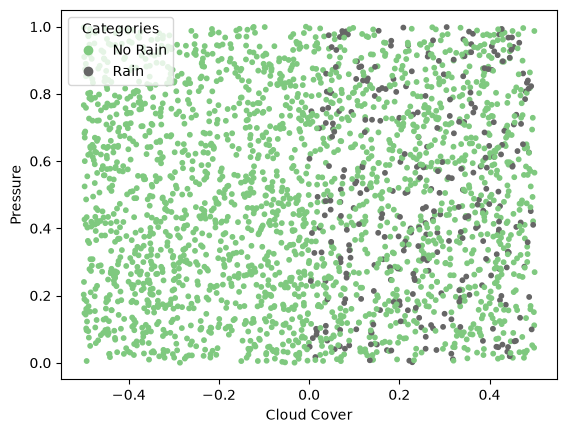

In [ ]:
scatter = plt.scatter(x_train[:, 0], x_train[:,1],c = y_train, cmap = 'Accent', s = 10)
plt.xlabel("Cloud Cover (-0.5)")
plt.ylabel("Pressure in (-980 and /7)")
plt.legend(handles=scatter.legend_elements()[0], labels=["No Rain", "Rain"], 
           title="Categories", loc = 2)
plt.show()

Defining the sigmoid function used for logistic regression.

In [232]:
def sigmoid(x):
    return 1 / (1 + np.exp(-1 * x))

Defining the gradient function for logistic regression given training features and results (X, y) and "guesses" for the variables w_1, w_2, and b.

In [233]:
def compute_gradient_logistic(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        err_i = f_wb_i - y[i]
        dj_dw += err_i * X[i]
        dj_db += err_i

    dj_dw  /= m
    dj_db /= m
    
    return dj_dw, dj_db

The actual gradient descent function that loops over the gradient logistic and updates w and b based on what was learned.

In [234]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    w = w_in
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

    return w, b

Computing the actual case for the weather forecast. The number of iterations and alpha took a bit of workshopping to get a reasonably accurate boundary line, but these numbers seemed to work.

In [ ]:
w_tmp = np.zeros_like(x_train[0])
b_tmp = 0
alpha = 0.1
iters = 5000
w_f, b_f = gradient_descent(x_train, y_train, w_tmp, b_tmp, alpha, iters)
print(w_f)
print(b_f)


[ 3.95053903 -0.07002063]
[-2.33965162]


Same scatterplot, but this time with a boundary line. The x and y intercepts are found from the 3-D model and slope then found from that. Then, using np.arange, baseline and prediction arrays are created, which are then plotted as the decision boundary.

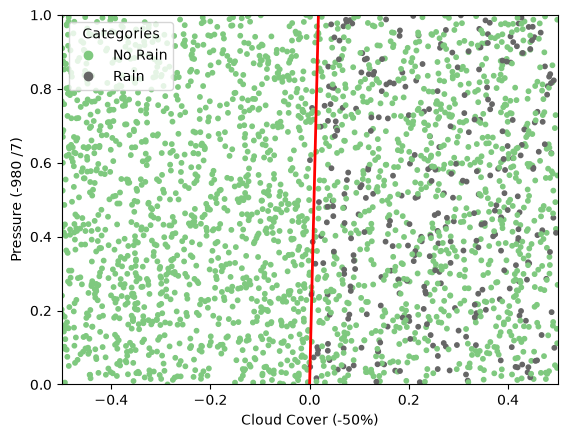

In [259]:
scatter = plt.scatter(x_train[:, 0], x_train[:,1],c = y_train, cmap = 'Accent', s = 10)
plt.xlabel("Cloud Cover (-50%)")
plt.ylabel("Pressure (-980 /7)")
plt.legend(handles=scatter.legend_elements()[0], labels=["No Rain", "Rain"], 
           title="Categories", loc = 2)

x0 = -b_f/w_f[0]
x1 = -b_f/w_f[1]
slope = -x1[0]/x0[0]

x_predict = np.arange(100)
y_predict = x_predict * slope
plt.plot(x_predict, y_predict, lw = 2, c = "r")

plt.xlim(-0.5, 0.5)
plt.ylim(0, 1)

plt.show()